In [6]:
# pytorch is open source deep learning framework created by Meta(facebook) that uses tensors

import torch

In [7]:
import sys
print(sys.executable)

C:\Users\krupa\anaconda3\python.exe


In [25]:
class Value:
    
    def __init__(self, data , _children = () , _op = '' , label = ''):
        self.data = data
        self.grad = 0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda:None
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance (other , Value) else Value(other)
        out = Value(self.data + other.data , (self , other) , '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    
    def __radd__(self , other):
        return self + other
    
    def __mul__(self , other):
        other = other if isinstance (other , Value) else Value(other)
        out = Value(self.data * other.data , (self , other) , '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    
    def __rmul__(self , other):      # other * self
        return self * other 
    
        
    def __truediv__(self , other):           # self / other
        return self * other**-1
    
    def __rtruediv__(self , other):          # other / self
        return other* self**-1
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self , other):     # self - other
        return self + (-other)
    
    def __rsub__(self , other):     # other - self
        return other + (-self)
    
    def __pow__(self , other):
        assert isinstance(other , (float , int))      #only supporting float and int
        out = Value(self.data ** other , (self, ) , f'**{other}')
        
        def _backward():
            self.grad += other * (self.data ** (other -1)) * out.grad
        out._backward = _backward
        
        return out
    

    def relu(self):
        out = Value(0 if self.data < 0 else self.data , (self, ) , "ReLu")
        
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        
        return out
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t , (self, ) , 'tanh' )
        
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x) , (self , ) , 'exp')
        
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [26]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes , edges = set() , set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child , v))
                build(child)
    build(root)
    return nodes , edges

def draw_dot(root):
    dot = Digraph(format = 'svg' , graph_attr = {'rankdir' : 'LR'})  # LR = Left to Right
    
    # fetches all nodes and edges 
    nodes , edges = trace(root)
    
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid , label = "{%s | data %.4f | grad %.4f}" % (n.label , n.data , n.grad) , shape = "record" )
        
        if(n._op):
            dot.node(name = uid + n._op , label = n._op)
            dot.edge(uid + n._op , uid)
    
    for n1,n2 in edges:
        dot.edge(str(id(n1)) , str(id(n2)) + n2._op)
      
    return dot

In [27]:
import random
import math

In [28]:
torch.tensor([[1,2,3], [4,5,6]])

tensor([[1, 2, 3],
        [4, 5, 6]])

In [12]:
# o.item() and o.data.item() will produce the same result in PyTorch
x1 = torch.tensor([2.0]).double();        x1.requires_grad = True;
x2 = torch.tensor([0.0]).double();        x2.requires_grad = True;
w1 = torch.tensor([-3.0]).double();       w1.requires_grad = True;
w2 = torch.tensor([1.0]).double();        w2.requires_grad = True;
b = torch.tensor([6.881373]).double();     b.requires_grad = True;
n  = x1*w1 + x2*w2 + b;
o = torch.tanh(n);

print(o.data)
print(o.data.item())
print(o.item())
print('-----')

o.backward()
print('x1' , x1.grad.item())
print('x2' , x2.grad.item())
print('w1' , w1.grad.item())
print('w2' , w2.grad.item())

tensor([0.7071], dtype=torch.float64)
0.7071064519863152
0.7071064519863152
-----
x1 -1.500001396677975
x2 0.500000465559325
w1 1.00000093111865
w2 0.0


In [13]:
class Neuron:
    
    def __init__(self  ,  nin):
        self.w = [Value(random.uniform(-1 , 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1 , 1))
        
    def __call__(self , x):
        act = sum((wi*xi for wi , xi  in zip(self.w , x)) , self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
    
class Layer:                   # group of neurons
    
    def __init__(self , nin , nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
        
    def __call__(self , x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        # return [p for neuron in self.neurons for p in neuron.parameters()]
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params
    
class MLP:                   # group of layers
    
    def __init__(self , nin , nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i] , sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self , x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        params = []
        for layer in self.layers:
            ps = layer.parameters()
            params.extend(ps)
        return params
    
x = [2.0 , 3.0 , -1.0]
n = MLP(3, [4,4,1])
n(x)

Value(data=-0.839830396389997)

In [14]:
# collecting all of the parameters of the neural network (parameters of neural network are weights and bias)
n.parameters()
len(n.parameters())

41

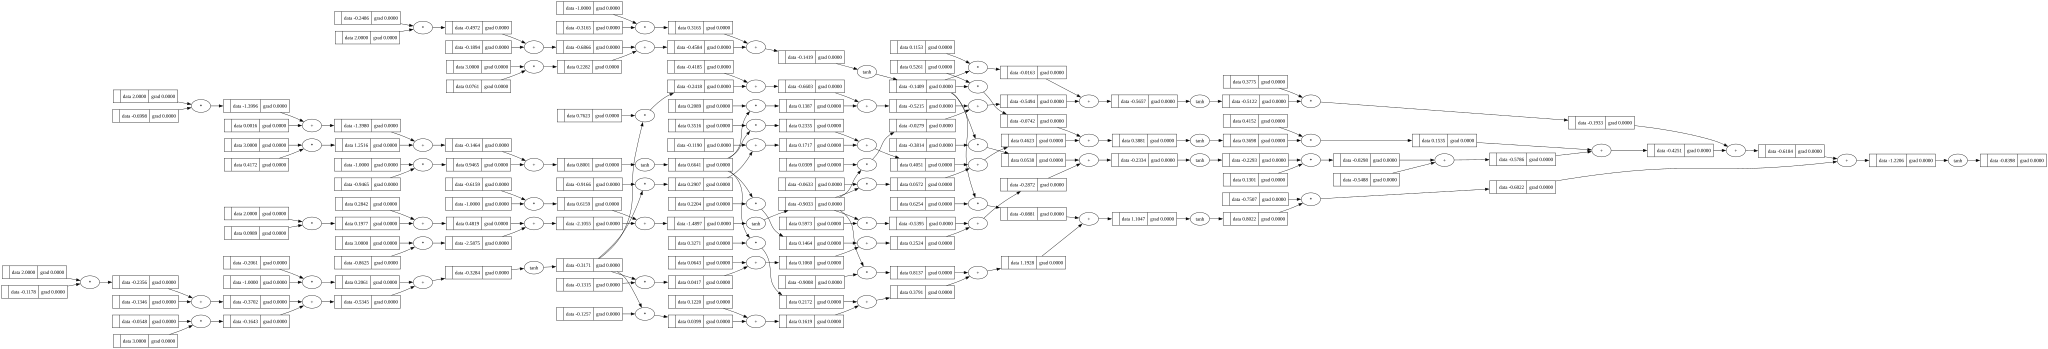

In [15]:
draw_dot(n(x))

In [16]:
xs = [
    [2.0 , 3.0 , -1.0],
    [3.0 , -1.0 , 0.5],
    [0.5 , 1.0 , 1.0],
    [1.0 , 1.0 , -1.0]
]
ys = [1.0 , -1.0 , -1.0 , 1.0]

In [17]:
# write loss function (mean square error)
ypred = [n(x) for x in xs]
loss = sum([(yout - ygt)**2  for ygt , yout in zip(ys , ypred)])
print(ypred)
print("---")
print(loss)

[Value(data=-0.839830396389997), Value(data=-0.28939318831250427), Value(data=-0.8378672823176865), Value(data=-0.6140260177618416)]
---
Value(data=6.521304932452443)


In [18]:
loss.backward()

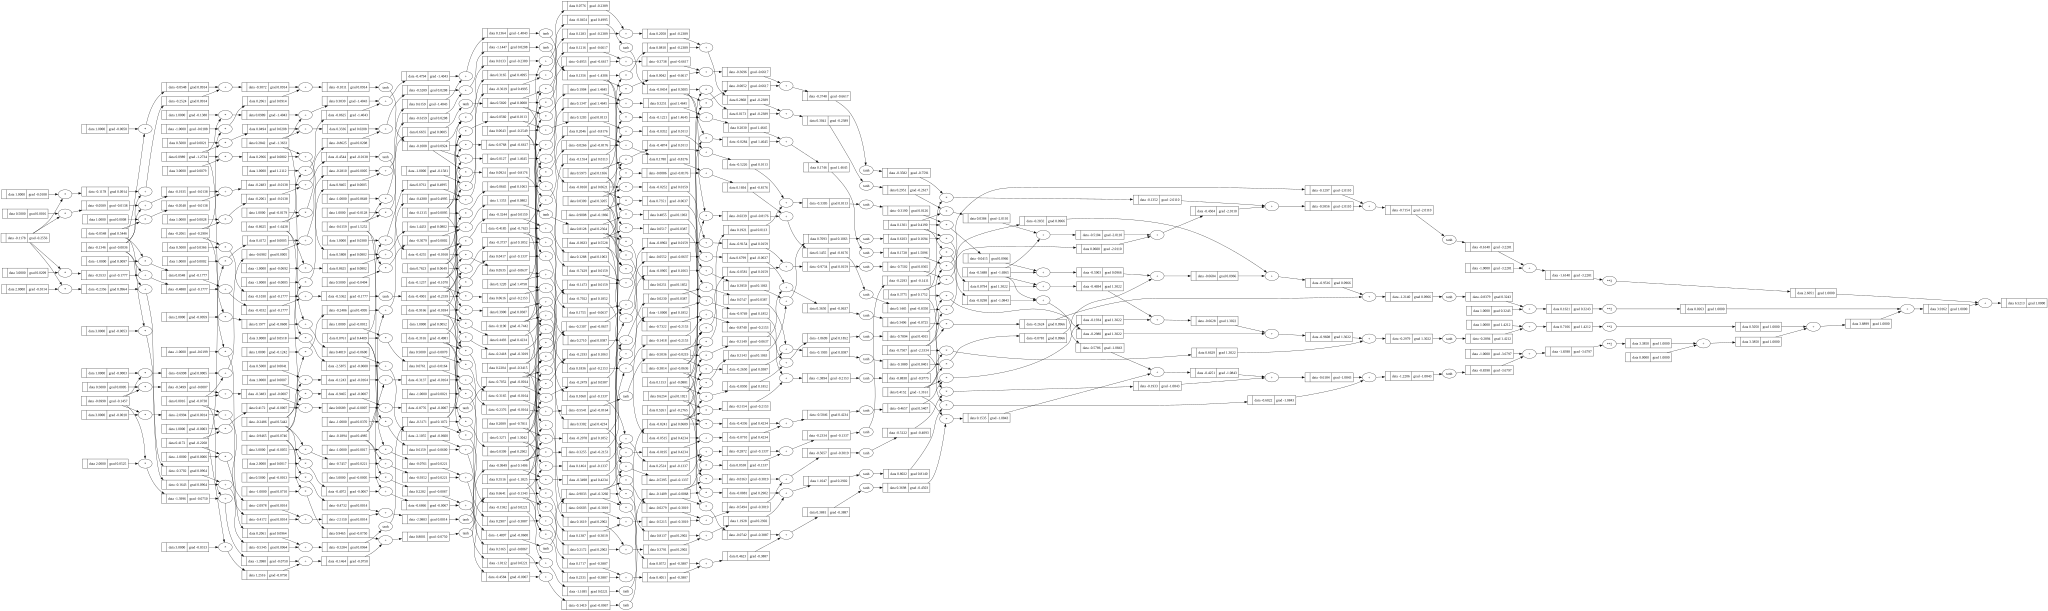

In [19]:
draw_dot(loss)

In [20]:
n.layers[0].neurons[0].w[0].grad

-0.2556481066572723

In [21]:
n.layers[0].neurons[0].w[0].data

-0.1177815788816452

In [22]:
# gradient Descent (iterate forward pass , backward pass and update)
for k in range(300):           # k is number of steps
    
    # forward pass 
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt)**2  for ygt , yout in zip(ys , ypred)])
    
    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    
    # update
    for p in n.parameters():
        p.data += -0.1 * p.grad
    
#     print(k , loss.data)

In [23]:
n.layers[0].neurons[0].w[0].data

0.02933929472030043

In [24]:
ypred

[Value(data=0.9848770459404562),
 Value(data=-0.9768957343261105),
 Value(data=-0.9904981814388606),
 Value(data=0.9831149611181796)]